# DarkNESS ALP allowed-signal ceiling

This notebook is a **go/no-go theory screen** for a DarkNESS-class follow-on mission using

$$\phi_{\rm DM}\rightarrow a+a,\qquad a+B_\oplus\rightarrow\gamma+B_\oplus.$$

It calculates two deliberately simple observables:

1. a cosmological-continuum ceiling normalized to the Suzaku/Yamamoto surface-brightness limit;
2. a Galactic monoenergetic ALP line using an editable field-of-view averaged decay $D$-factor.

Both are folded through a direct-view DarkNESS grasp, exposure, efficiency, geomagnetic conversion probability, and a uniform-field coherence estimate. This is not a final sensitivity forecast: it asks whether the largest externally allowed signal is even in the detectable-count regime before a background model or scheduler is built.

Primary references: [DarkNESS mission](https://doi.org/10.1016/j.asr.2025.07.070), [Yamamoto et al.](https://arxiv.org/abs/1906.04429), [CAST coupling bound](https://arxiv.org/abs/2406.16840), and [invisible-DM-decay cosmology](https://arxiv.org/abs/1606.02073).

## Model and scaling

For a parent-DM decay source independent of the photon coupling,

$$N_\gamma\propto g_{a\gamma\gamma}^2\,\frac{f_\phi\,\mathrm{Br}(\phi\to aa)}{\tau_\phi}.$$

The rate is **not** proportional to $g^4$. A $g^4$ rate applies when production is also controlled by the photon coupling, as in a minimal solar-axion helioscope.

For the conversion step this notebook uses Yamamoto's convenient normalization

$$P_{a\to\gamma}\simeq 2.45\times10^{-21}\left(\frac{g_{a\gamma\gamma}}{10^{-10}\,\mathrm{GeV}^{-1}}\right)^2\left(\frac{B_\perp L}{1\,\mathrm{T\,m}}\right)^2 C(m_a,E,L),$$

with the uniform-field coherence factor

$$C=\left[\frac{\sin(qL/2)}{qL/2}\right]^2,\qquad q=\frac{m_a^2}{2E}.$$

A final mission calculation should replace the single-length coherence approximation with the repository's phase-aware vector line-of-sight integral.

In [1]:
from dataclasses import dataclass
import math

import matplotlib.pyplot as plt
import numpy as np

HBAR_C_EV_M = 1.973269804e-7
ERG_PER_KEV = 1.602176634e-9
SECONDS_PER_GYR = 1.0e9 * 365.25 * 86400.0


## Editable inputs

The defaults intentionally reproduce the conservative screening question discussed in the manuscript review. Replace them as the theory and flight configuration are fixed.

- `effective_decay_rate_gyr_inv` means $f_\phi\,\mathrm{Br}(\phi\to aa)/\tau_\phi$.
- `d_factor_gev_cm2` is the **FOV-averaged** Galactic decay column, not an annihilation $J$-factor.
- `fov_full_angle_deg=20` treats the published 20-degree FOV as a full cone.
- `throughput` combines quantum efficiency, masking, and live fraction.
- `effective_path_m` controls only the approximate coherence envelope; $B_\perp L$ independently controls the coherent conversion amplitude.

In [2]:
@dataclass(frozen=True)
class TheoryInputs:
    parent_mass_kev: float = 7.0
    alp_photon_coupling_gev_inv: float = 5.8e-11
    effective_decay_rate_gyr_inv: float = 6.3e-3
    d_factor_gev_cm2: float = 1.0e23


@dataclass(frozen=True)
class GeometryInputs:
    b_perp_l_tm: float = 100.0
    effective_path_m: float = 4.0e7


@dataclass(frozen=True)
class InstrumentInputs:
    geometric_area_cm2: float = 12.0
    fov_full_angle_deg: float = 20.0
    throughput: float = 0.20
    exposure_s: float = 90_000.0


theory = TheoryInputs()
geometry = GeometryInputs()
instrument = InstrumentInputs()

# Yamamoto universal-continuum normalization (2-6 keV).
yamamoto_energy_flux_erg_cm2_s_sr = 1.6e-9
yamamoto_coupling_gev_inv = 3.3e-7
yamamoto_parent_lifetime_gyr = 4.32e17 / SECONDS_PER_GYR
yamamoto_b2_t2m2 = 1.0e4
continuum_band_kev = (2.0, 6.0)
continuum_number_slope = 0.5  # dN/dE proportional to E^(+1/2)


In [3]:
def cone_solid_angle_sr(full_angle_deg: float) -> float:
    half_angle_rad = math.radians(full_angle_deg / 2.0)
    return 2.0 * math.pi * (1.0 - math.cos(half_angle_rad))


def power_law_mean_energy_kev(e_min: float, e_max: float, number_slope: float) -> float:
    # Mean photon energy when dN/dE is proportional to E^number_slope.
    if np.isclose(number_slope, -1.0) or np.isclose(number_slope, -2.0):
        raise ValueError('The compact power-law integral needs a non-logarithmic slope.')
    numerator = (e_max ** (number_slope + 2.0) - e_min ** (number_slope + 2.0)) / (number_slope + 2.0)
    denominator = (e_max ** (number_slope + 1.0) - e_min ** (number_slope + 1.0)) / (number_slope + 1.0)
    return numerator / denominator


def coherence_uniform(ma_ev, energy_kev: float, path_m: float):
    ma_ev = np.asarray(ma_ev, dtype=float)
    energy_ev = energy_kev * 1.0e3
    q_per_m = ma_ev**2 / (2.0 * energy_ev * HBAR_C_EV_M)
    x = 0.5 * q_per_m * path_m
    # np.sinc(y) is sin(pi*y)/(pi*y).
    return np.sinc(x / np.pi) ** 2


def conversion_probability_coherent(g_gev_inv: float, b_perp_l_tm: float) -> float:
    return 2.45e-21 * (g_gev_inv / 1.0e-10) ** 2 * b_perp_l_tm**2


def galactic_line_alp_intensity_cm2_s_sr(
    parent_mass_kev: float, effective_decay_rate_gyr_inv: float, d_factor_gev_cm2: float
) -> float:
    parent_mass_gev = parent_mass_kev * 1.0e-6
    effective_rate_s_inv = effective_decay_rate_gyr_inv / SECONDS_PER_GYR
    # Two ALPs per decay and isotropic emission.
    return 2.0 * d_factor_gev_cm2 * effective_rate_s_inv / (4.0 * math.pi * parent_mass_gev)


def counts_from_intensity(intensity_cm2_s_sr, grasp_cm2_sr: float, exposure_s: float, throughput: float):
    return np.asarray(intensity_cm2_s_sr) * grasp_cm2_sr * exposure_s * throughput


def coupling_for_target_counts(reference_g: float, reference_counts: float, target_counts: float = 1.0) -> float:
    if reference_counts <= 0.0:
        return math.inf
    return reference_g * math.sqrt(target_counts / reference_counts)


## Coherent signal ceilings

The continuum calculation rescales the empirical Yamamoto brightness limit by the coupling squared, the effective parent decay rate, and $(B_\perp L)^2$. The Galactic calculation starts from the decay $D$-factor. The two estimates therefore answer complementary questions and should not be added as if they came from a single jointly normalized source model.

In [4]:
solid_angle_sr = cone_solid_angle_sr(instrument.fov_full_angle_deg)
grasp_cm2_sr = instrument.geometric_area_cm2 * solid_angle_sr
p_coherent = conversion_probability_coherent(
    theory.alp_photon_coupling_gev_inv, geometry.b_perp_l_tm
)

line_energy_kev = theory.parent_mass_kev / 2.0
line_alp_intensity = galactic_line_alp_intensity_cm2_s_sr(
    theory.parent_mass_kev, theory.effective_decay_rate_gyr_inv, theory.d_factor_gev_cm2
)
line_photon_intensity_coherent = line_alp_intensity * p_coherent
line_counts_coherent = float(
    counts_from_intensity(
        line_photon_intensity_coherent, grasp_cm2_sr, instrument.exposure_s, instrument.throughput
    )
)

mean_continuum_energy_kev = power_law_mean_energy_kev(
    *continuum_band_kev, continuum_number_slope
)
yamamoto_photon_intensity = yamamoto_energy_flux_erg_cm2_s_sr / (
    mean_continuum_energy_kev * ERG_PER_KEV
)
coupling_ratio = (theory.alp_photon_coupling_gev_inv / yamamoto_coupling_gev_inv) ** 2
decay_rate_ratio = theory.effective_decay_rate_gyr_inv / (1.0 / yamamoto_parent_lifetime_gyr)
geometry_ratio = geometry.b_perp_l_tm**2 / yamamoto_b2_t2m2
continuum_photon_intensity_coherent = (
    yamamoto_photon_intensity * coupling_ratio * decay_rate_ratio * geometry_ratio
)
continuum_counts_coherent = float(
    counts_from_intensity(
        continuum_photon_intensity_coherent, grasp_cm2_sr, instrument.exposure_s, instrument.throughput
    )
)

print(f'Solid angle:                  {solid_angle_sr:.4f} sr')
print(f'Geometric grasp:               {grasp_cm2_sr:.3f} cm^2 sr')
print(f'Coherent conversion P(a->g):  {p_coherent:.3e}')
print(f'Galactic ALP line intensity:   {line_alp_intensity:.3e} cm^-2 s^-1 sr^-1')
print(f'Galactic line photon counts:   {line_counts_coherent:.3e}')
print(f'Continuum mean photon energy:  {mean_continuum_energy_kev:.3f} keV')
print(f'Continuum photon counts:       {continuum_counts_coherent:.3e}')
print()
print('Coupling required for one coherent count at the same source normalization:')
print(f'  Galactic line: {coupling_for_target_counts(theory.alp_photon_coupling_gev_inv, line_counts_coherent):.3e} GeV^-1')
print(f'  Continuum:     {coupling_for_target_counts(theory.alp_photon_coupling_gev_inv, continuum_counts_coherent):.3e} GeV^-1')


Solid angle:                  0.0955 sr
Geometric grasp:               1.145 cm^2 sr
Coherent conversion P(a->g):  8.242e-18
Galactic ALP line intensity:   4.539e+08 cm^-2 s^-1 sr^-1
Galactic line photon counts:   7.713e-05
Continuum mean photon energy:  4.172 keV
Continuum photon counts:       1.315e-05

Coupling required for one coherent count at the same source normalization:
  Galactic line: 6.604e-09 GeV^-1
  Continuum:     1.600e-08 GeV^-1


## Mass-dependent coherence and count ceiling

The oscillatory structure below is the uniform-field approximation. A nonuniform geomagnetic field smooths and shifts it; the scientifically relevant feature here is the onset of coherence loss.

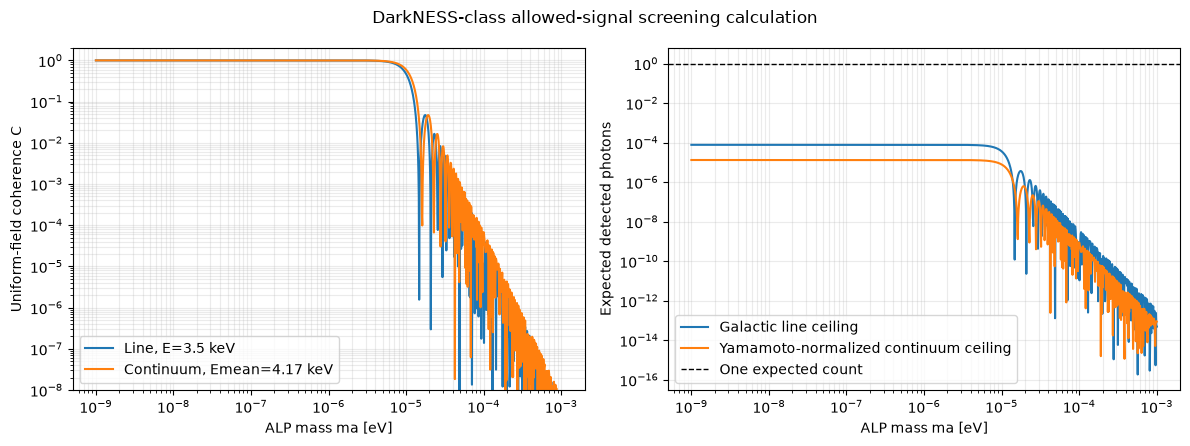

In [5]:
ma_grid_ev = np.geomspace(1.0e-9, 1.0e-3, 1200)
line_coherence = coherence_uniform(ma_grid_ev, line_energy_kev, geometry.effective_path_m)
continuum_coherence = coherence_uniform(
    ma_grid_ev, mean_continuum_energy_kev, geometry.effective_path_m
)
line_counts_vs_mass = line_counts_coherent * line_coherence
continuum_counts_vs_mass = continuum_counts_coherent * continuum_coherence

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].loglog(ma_grid_ev, line_coherence, label=f'Line, E={line_energy_kev:g} keV')
axes[0].loglog(ma_grid_ev, continuum_coherence, label=f'Continuum, Emean={mean_continuum_energy_kev:.2f} keV')
axes[0].set_xlabel('ALP mass ma [eV]')
axes[0].set_ylabel('Uniform-field coherence C')
axes[0].set_ylim(1e-8, 2)
axes[0].grid(True, which='both', alpha=0.25)
axes[0].legend()

axes[1].loglog(ma_grid_ev, line_counts_vs_mass, label='Galactic line ceiling')
axes[1].loglog(ma_grid_ev, continuum_counts_vs_mass, label='Yamamoto-normalized continuum ceiling')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1, label='One expected count')
axes[1].set_xlabel('ALP mass ma [eV]')
axes[1].set_ylabel('Expected detected photons')
axes[1].grid(True, which='both', alpha=0.25)
axes[1].legend()

fig.suptitle('DarkNESS-class allowed-signal screening calculation')
fig.tight_layout()
plt.show()


## Decision and next required evidence

Interpret this notebook as follows:

- If an externally allowed ceiling is already far below one count, detailed orbit optimization cannot rescue that minimal theory benchmark.
- If the ceiling reaches a useful count regime, the next calculation must use the phase-aware FOV integral and an executable orbit/attitude schedule.
- A sensitivity or discovery statement additionally requires a DarkNESS-specific orbital event spectrum, live/masked-area history, and background proxies. The relevant statistic is the residual covariance between the predicted conversion regressor and those background proxies—not the raw count total alone.

### Inputs still needing authoritative values

1. Full-angle versus half-angle convention and off-axis aperture response.
2. Energy-dependent effective area, live fraction, and masking fraction.
3. FOV-averaged Galactic decay $D$-factor for the chosen pointing.
4. The exact cosmological bound appropriate to the selected parent lifetime and decaying fraction.
5. Phase-aware $B_\perp$ integration over the actual FOV and candidate orbit.
6. Measured or conservatively bounded LEO background counts and their orbit/detector covariates.